In [1]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load Dataset
df = pd.read_csv("Crop_Recommendation.csv")

# Basic Info
print("\n Dataset Overview:")
print(df.info())
print("\n First 5 Rows:")
print(df.head())


 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

 First 5 Rows:
   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        90          42         43    20.879744  82.002744  6.502985   
1        85          58         41    21.770462  80.319644  7.038096   
2        60          55         44    23.004459  82.320763  7.840207   
3        74          35         40    26.491096  80.158363  6.980401   
4        

In [2]:
# Structured Statistical Summary using Tabulate
summary = df.describe()
print("\n Statistical Summary:")
print(tabulate(summary, headers='keys', tablefmt='grid'))


 Statistical Summary:
+-------+------------+--------------+-------------+---------------+------------+-------------+------------+
|       |   Nitrogen |   Phosphorus |   Potassium |   Temperature |   Humidity |    pH_Value |   Rainfall |
+=======+============+==============+=============+===============+============+=============+============+
| count |  2200      |    2200      |   2200      |    2200       |  2200      | 2200        |  2200      |
+-------+------------+--------------+-------------+---------------+------------+-------------+------------+
| mean  |    50.5518 |      53.3627 |     48.1491 |      25.6162  |    71.4818 |    6.46948  |   103.464  |
+-------+------------+--------------+-------------+---------------+------------+-------------+------------+
| std   |    36.9173 |      32.9859 |     50.6479 |       5.06375 |    22.2638 |    0.773938 |    54.9584 |
+-------+------------+--------------+-------------+---------------+------------+-------------+------------+
| min

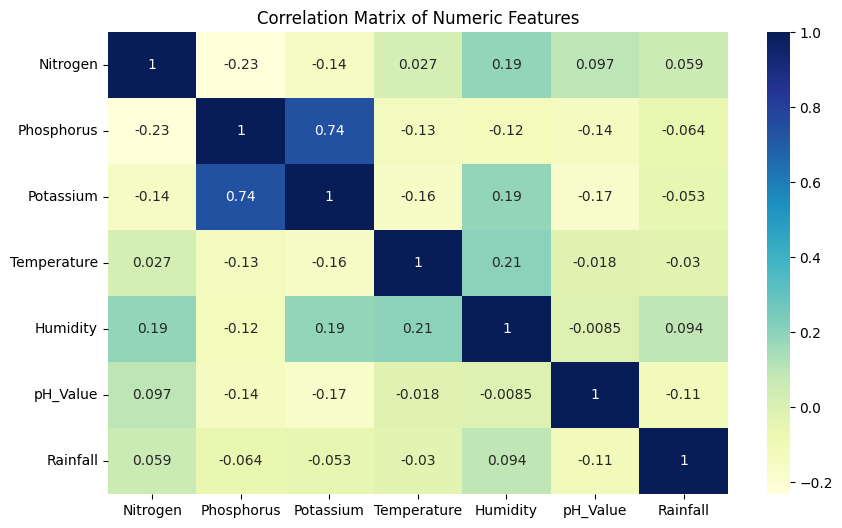

In [3]:
# Correlation Heatmap - Only for Numeric Columns
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Matrix of Numeric Features")
plt.show()


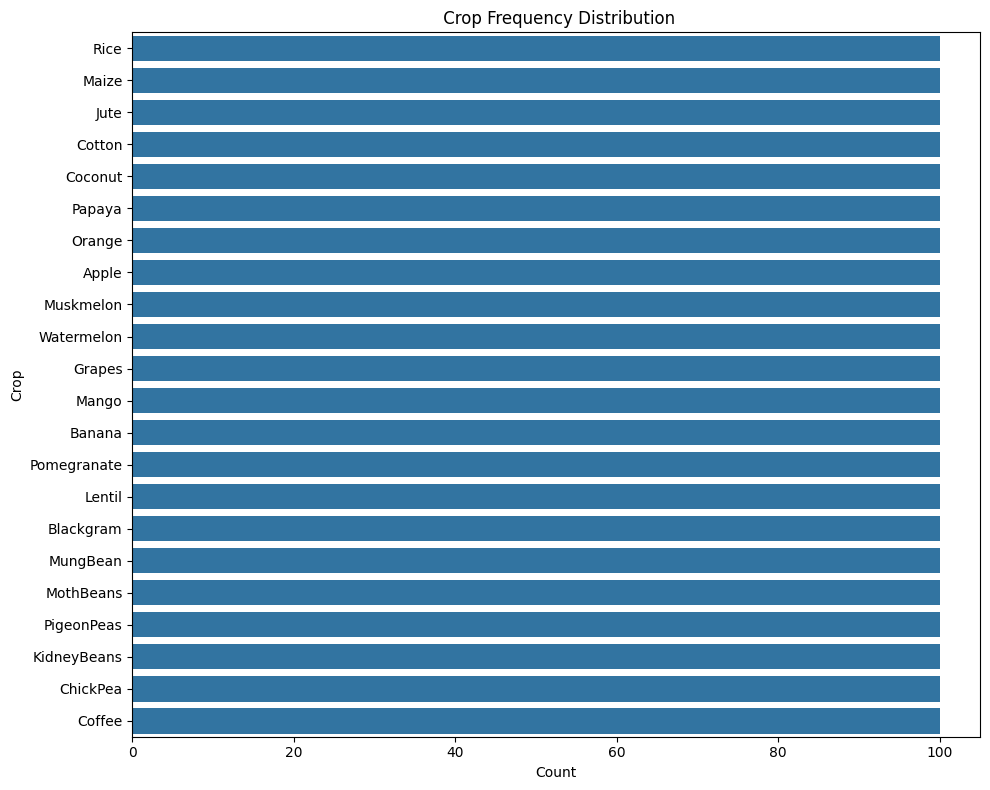

In [5]:
# Crop Count Distribution
plt.figure(figsize=(10, 8))
sns.countplot(y="Crop", data=df, order=df["Crop"].value_counts().index)
plt.title(" Crop Frequency Distribution")
plt.xlabel("Count")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

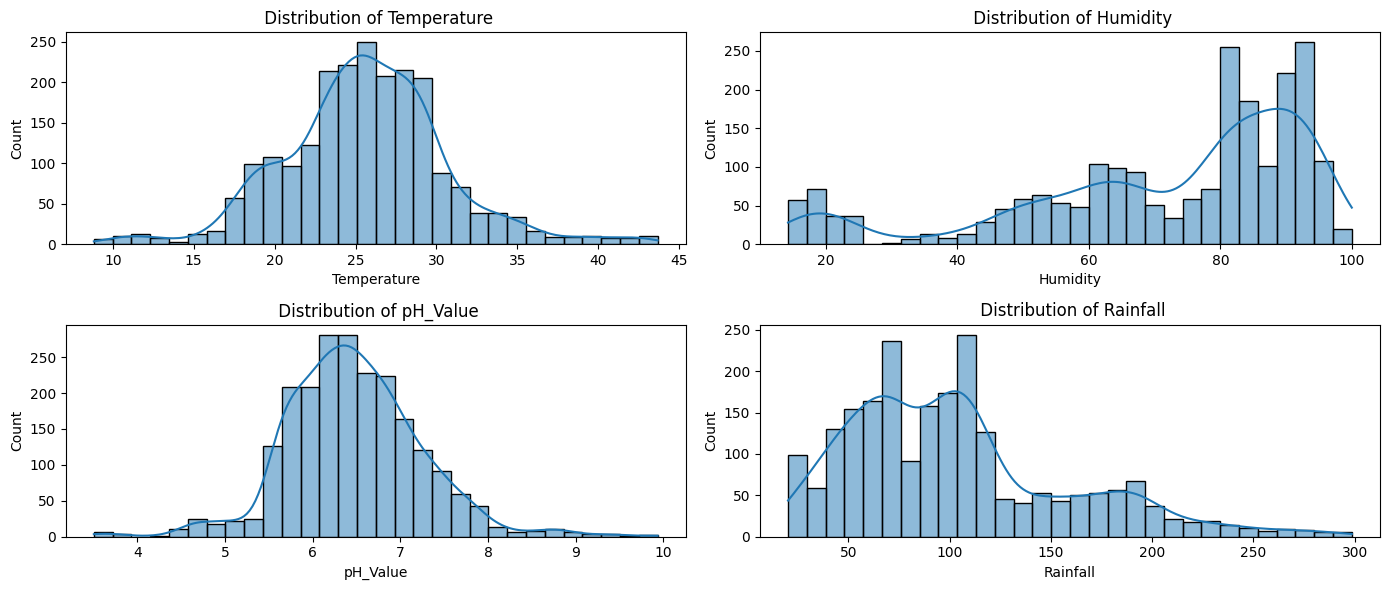

In [7]:
# Distribution of Numerical Features
plt.figure(figsize=(14, 6))
for i, column in enumerate(["Temperature", "Humidity", "pH_Value", "Rainfall"], 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f" Distribution of {column}")
plt.tight_layout()
plt.show()

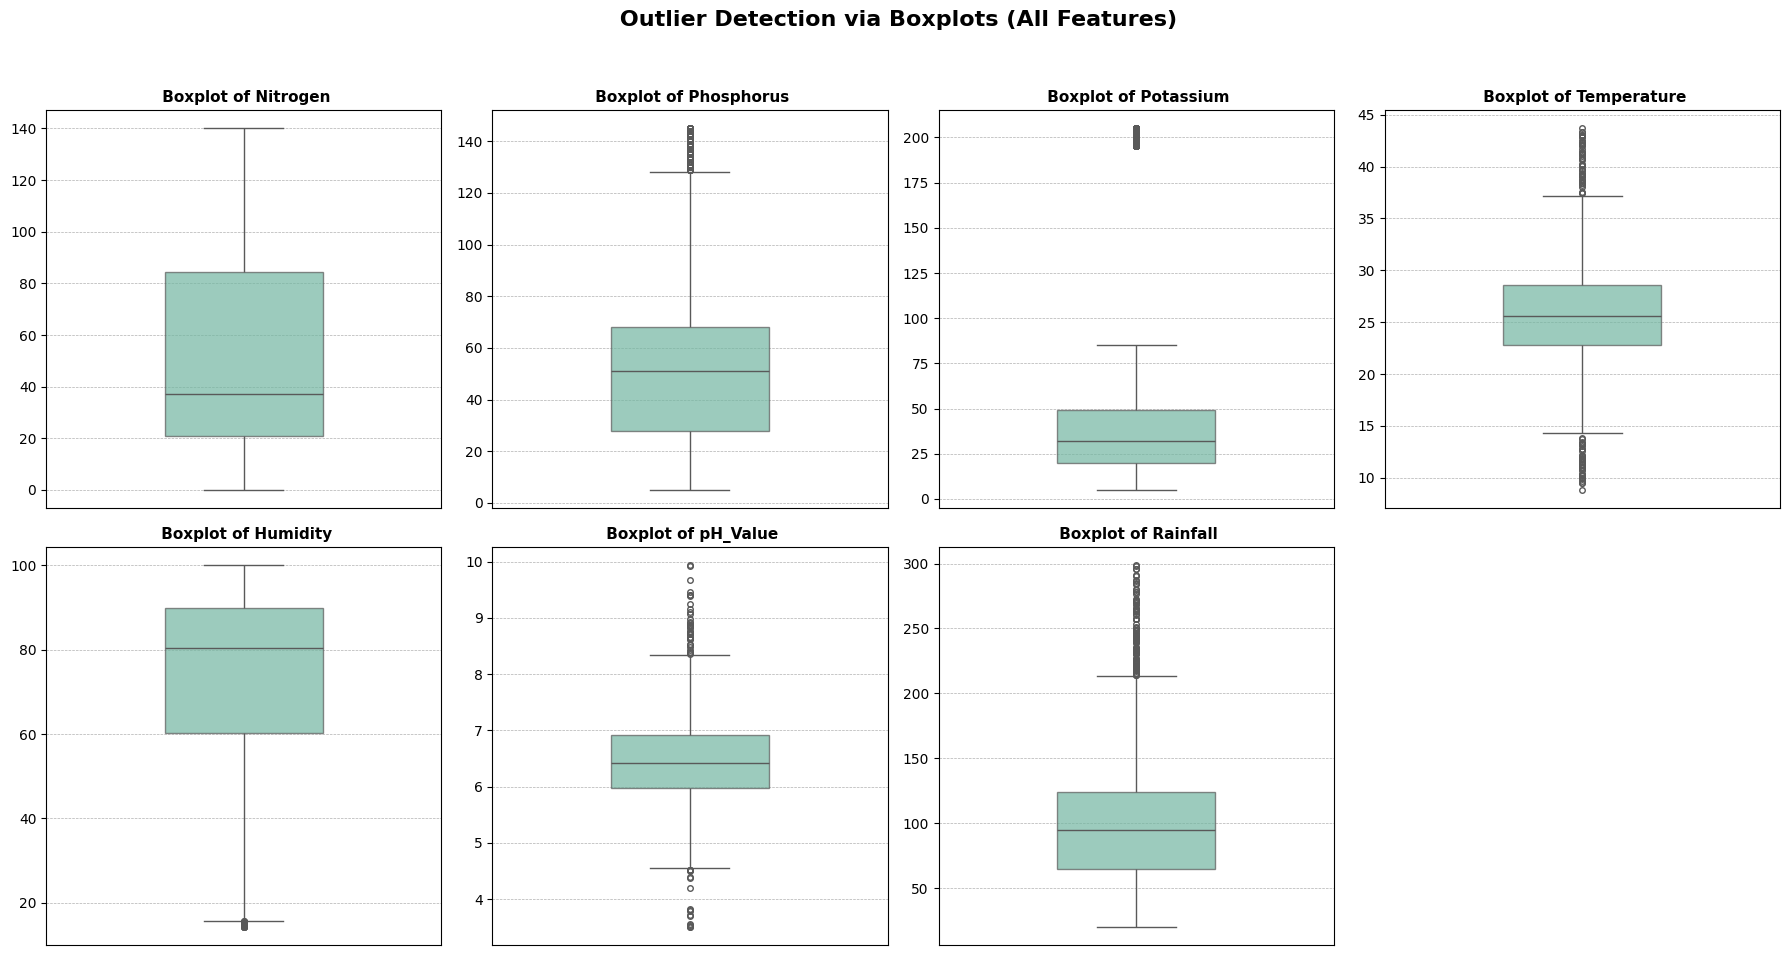

In [8]:
# Enhanced Boxplots for Outlier Detection with Aesthetics
numerical_cols = ["Nitrogen", "Phosphorus", "Potassium", "Temperature", "Humidity", "pH_Value", "Rainfall"]

plt.figure(figsize=(18, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[column], palette="Set2", width=0.4, fliersize=4, boxprops=dict(alpha=0.7))
    plt.title(f" Boxplot of {column}", fontsize=11, weight='bold')
    plt.ylabel("")  # Clean Y-axis label
    plt.grid(axis='y', linestyle='--', linewidth=0.5)
    plt.xticks([])

plt.suptitle(" Outlier Detection via Boxplots (All Features)", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [9]:
# Missing Values Check
print("\n Missing Values (Before Cleaning):")
print(df.isnull().sum())

# No missing values, but let's demonstrate cleaning
df_cleaned = df.dropna()

print("\n Missing Values (After Cleaning):")
print(df_cleaned.isnull().sum())


 Missing Values (Before Cleaning):
Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

 Missing Values (After Cleaning):
Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64


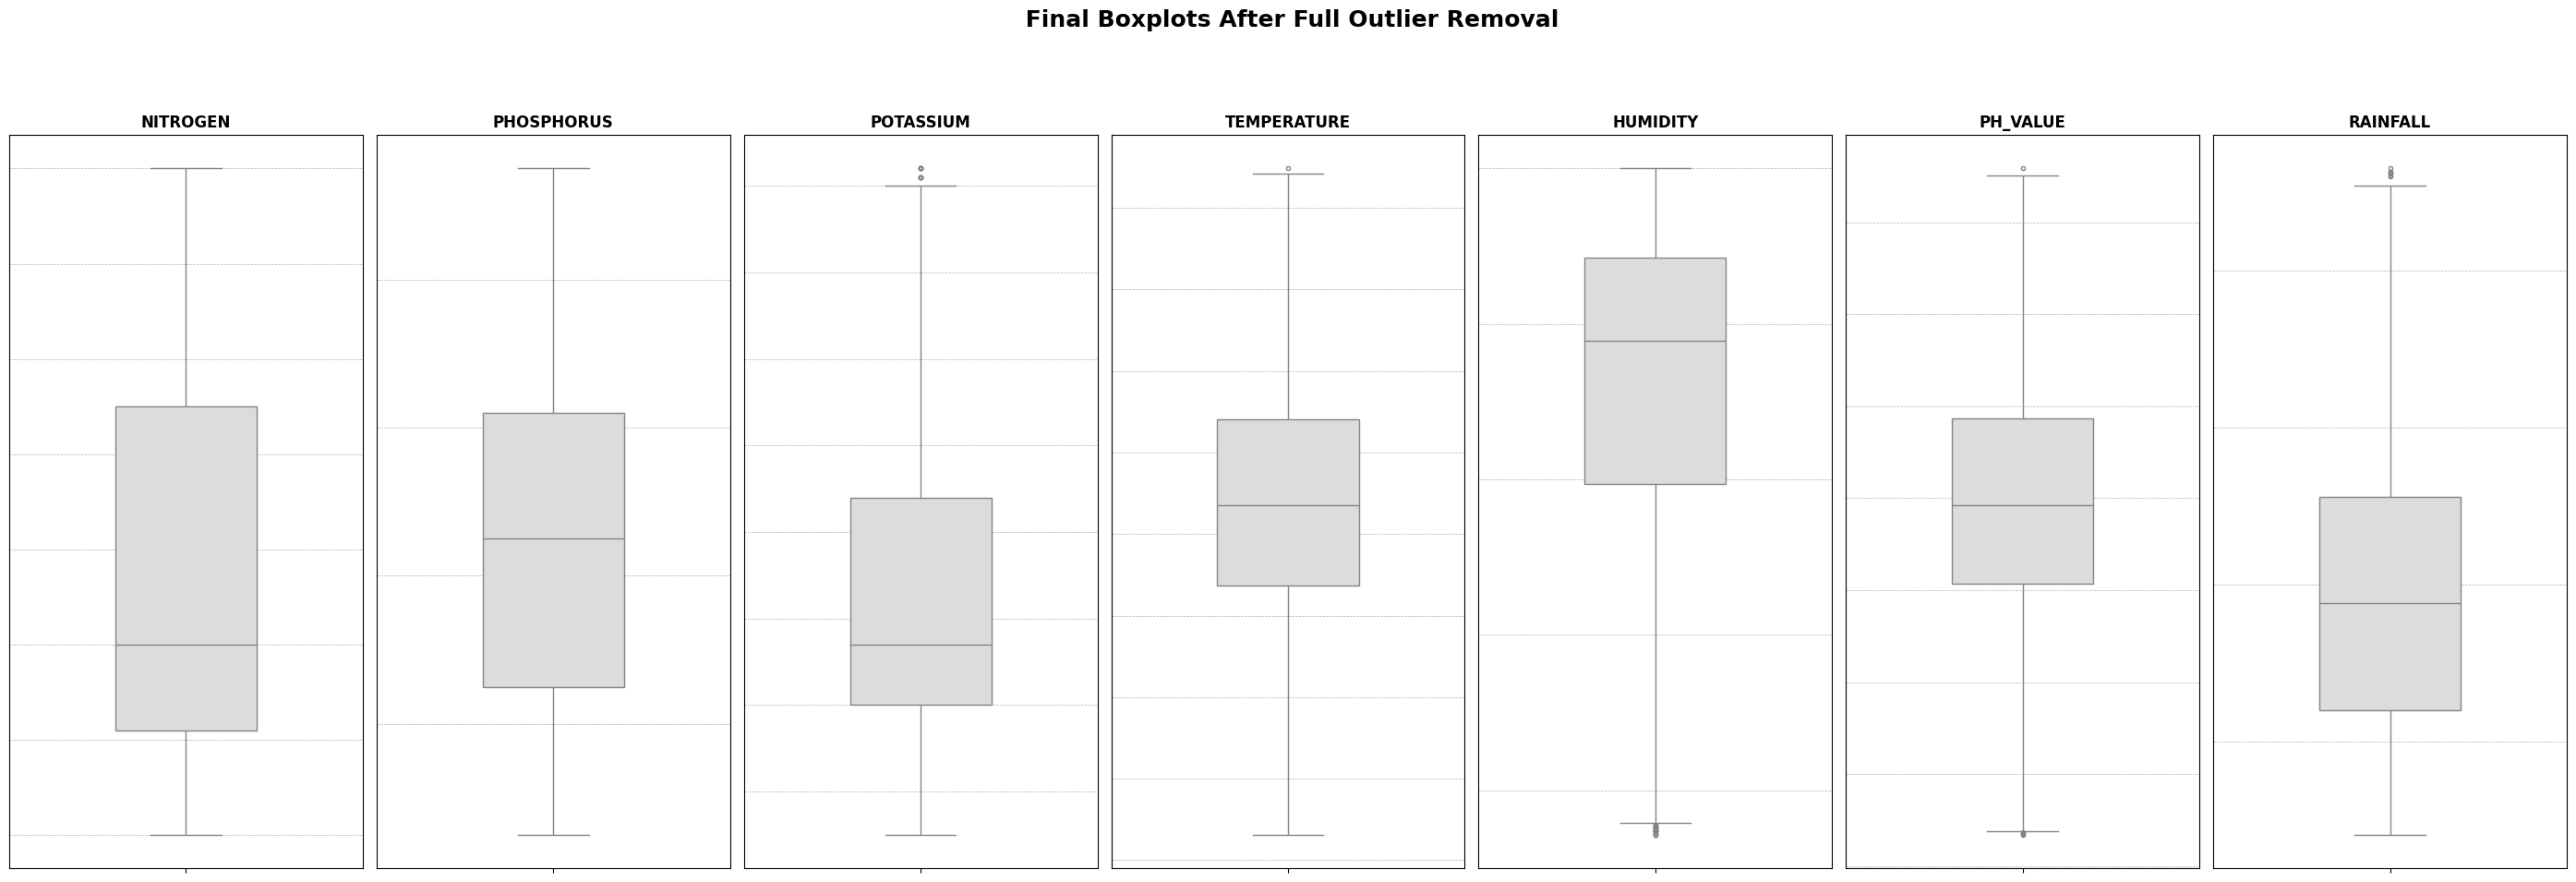

In [10]:
# IQR Outlier Removal: Recursive Until Converged
def remove_all_outliers_iqr(data, column, max_iter=5):
    for _ in range(max_iter):
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        new_data = data[(data[column] >= lower) & (data[column] <= upper)]
        if new_data.shape[0] == data.shape[0]:
            break
        data = new_data
    return data

# Apply recursively to all numeric columns
df_iter_cleaned = df_cleaned.copy()
for col in numerical_cols:
    df_iter_cleaned = remove_all_outliers_iqr(df_iter_cleaned, col)

# Recheck: Boxplots After Full Recursive Cleaning (Larger + Clean)
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(28, 10))
fig.suptitle(" Final Boxplots After Full Outlier Removal", fontsize=18, weight='bold')

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_iter_cleaned[col], ax=axes[i], palette="coolwarm", width=0.4, fliersize=3)
    axes[i].set_title(col.upper(), fontsize=12, weight='bold')
    axes[i].set_ylabel("")
    axes[i].grid(axis='y', linestyle='--', linewidth=0.5)
    axes[i].tick_params(left=False, labelleft=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()



 Crop Class Distribution After Outlier Removal:
Crop
Banana         100
Pomegranate    100
Jute           100
Cotton         100
Coconut        100
Muskmelon      100
Watermelon     100
Maize          100
Coffee         100
Lentil         100
Blackgram      100
MungBean       100
KidneyBeans     96
Mango           95
PigeonPeas      91
Orange          80
ChickPea        61
MothBeans       54
Papaya          53
Rice            48
Name: count, dtype: int64


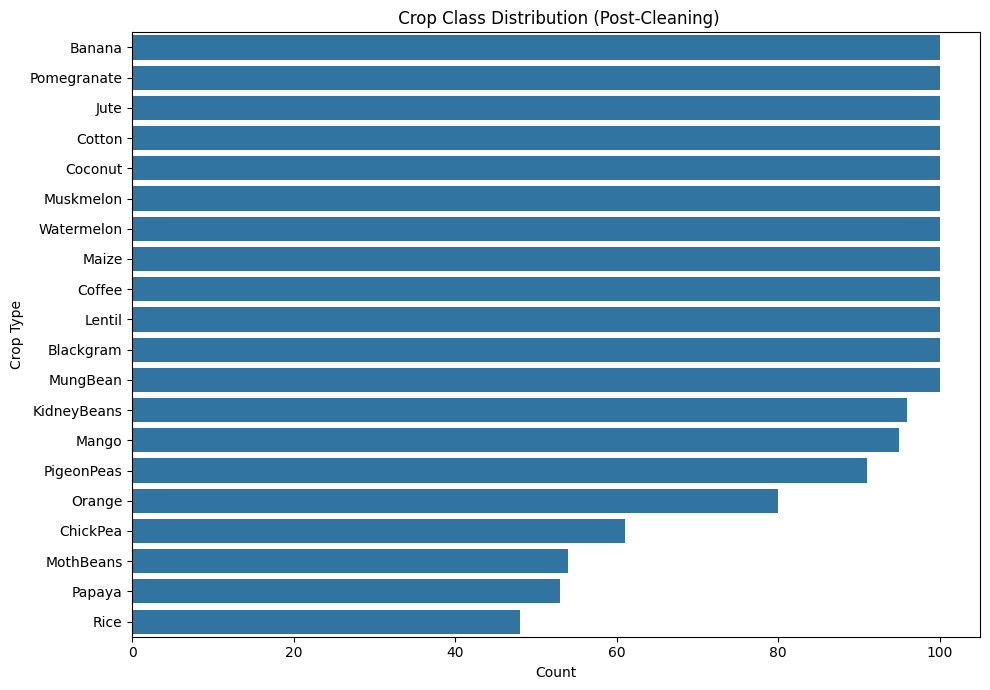

In [12]:
# Class Imbalance Check
print("\n Crop Class Distribution After Outlier Removal:")
print(df_iter_cleaned['Crop'].value_counts())

# Visual Class Distribution Post-Cleaning
plt.figure(figsize=(10, 7))
sns.countplot(data=df_iter_cleaned, y='Crop', order=df_iter_cleaned['Crop'].value_counts().index)
plt.title(" Crop Class Distribution (Post-Cleaning)")
plt.xlabel("Count")
plt.ylabel("Crop Type")
plt.tight_layout()
plt.show()


# Implementing ML Models


 Training Decision Tree...
 Classification Report for Decision Tree:

              precision    recall  f1-score   support

      Banana       0.96      1.00      0.98        22
   Blackgram       1.00      1.00      1.00        22
    ChickPea       1.00      1.00      1.00        10
     Coconut       1.00      1.00      1.00        22
      Coffee       1.00      1.00      1.00        25
      Cotton       1.00      0.91      0.95        11
        Jute       0.89      0.89      0.89        18
 KidneyBeans       1.00      1.00      1.00        22
      Lentil       1.00      1.00      1.00        12
       Maize       0.95      1.00      0.97        19
       Mango       1.00      1.00      1.00        20
   MothBeans       1.00      1.00      1.00        13
    MungBean       1.00      1.00      1.00        24
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00      1.00      1.00        17
      Papaya       1.00      0.86      0.92        14
  PigeonPe

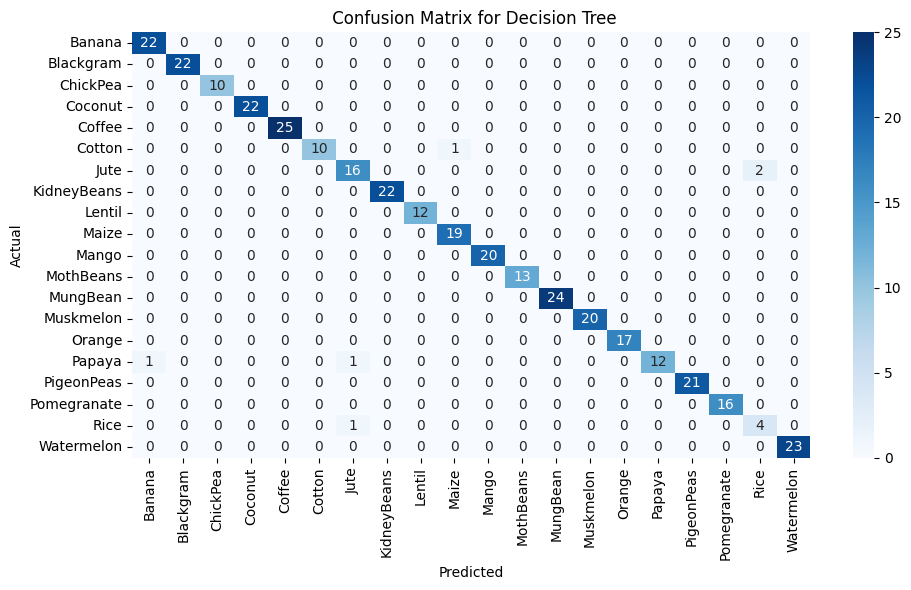


 Training Random Forest...
 Classification Report for Random Forest:

              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00        22
   Blackgram       0.96      1.00      0.98        22
    ChickPea       1.00      1.00      1.00        10
     Coconut       1.00      1.00      1.00        22
      Coffee       1.00      1.00      1.00        25
      Cotton       1.00      1.00      1.00        11
        Jute       0.94      0.94      0.94        18
 KidneyBeans       1.00      1.00      1.00        22
      Lentil       1.00      1.00      1.00        12
       Maize       1.00      1.00      1.00        19
       Mango       1.00      1.00      1.00        20
   MothBeans       1.00      0.92      0.96        13
    MungBean       1.00      1.00      1.00        24
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00      1.00      1.00        17
      Papaya       1.00      1.00      1.00        14
  PigeonPe

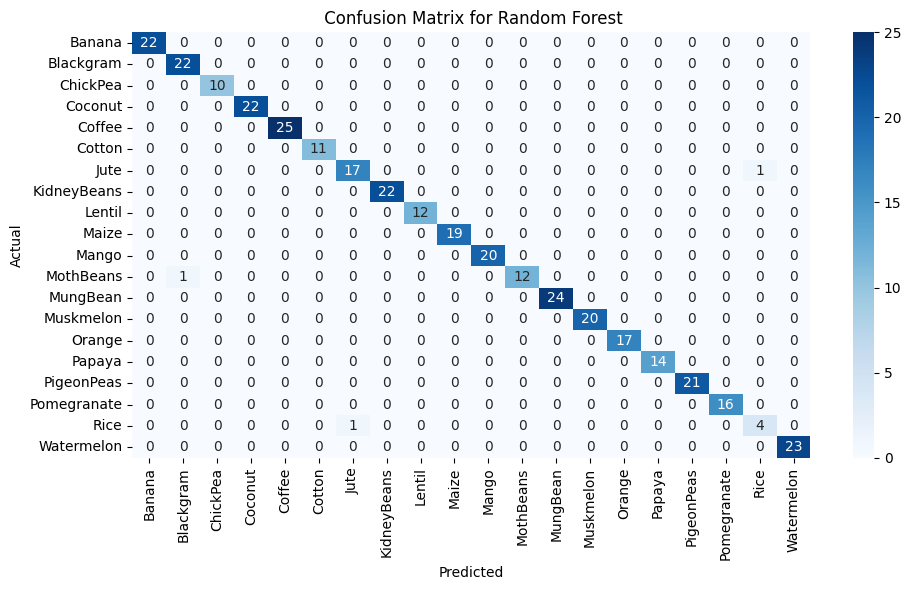


 Training SVM...
 Classification Report for SVM:

              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00        22
   Blackgram       1.00      1.00      1.00        22
    ChickPea       1.00      1.00      1.00        10
     Coconut       1.00      1.00      1.00        22
      Coffee       0.96      1.00      0.98        25
      Cotton       1.00      1.00      1.00        11
        Jute       0.94      0.89      0.91        18
 KidneyBeans       0.92      1.00      0.96        22
      Lentil       1.00      1.00      1.00        12
       Maize       1.00      1.00      1.00        19
       Mango       1.00      1.00      1.00        20
   MothBeans       1.00      1.00      1.00        13
    MungBean       1.00      1.00      1.00        24
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00      1.00      1.00        17
      Papaya       1.00      0.93      0.96        14
  PigeonPeas       1.00      0

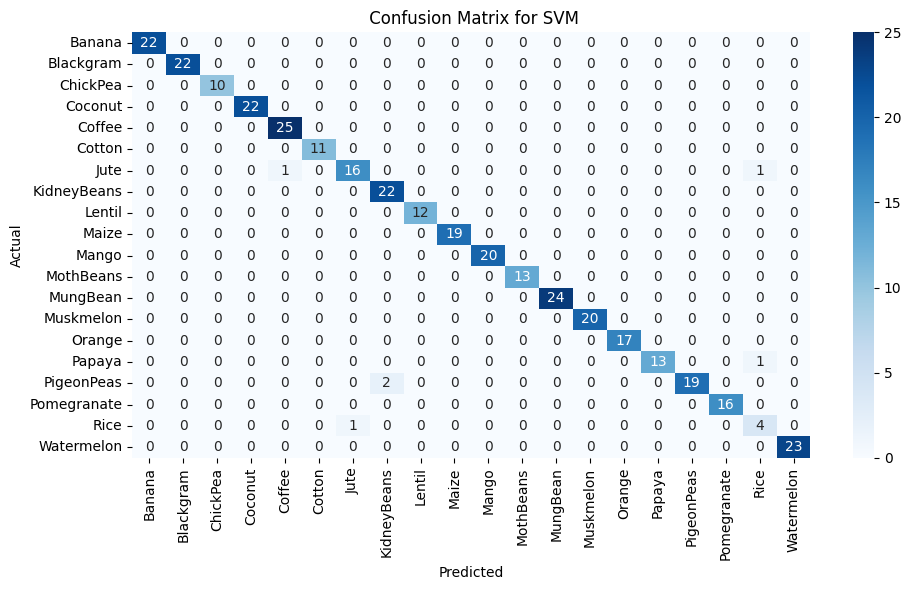


 Training Logistic Regression...
 Classification Report for Logistic Regression:

              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00        22
   Blackgram       0.91      0.95      0.93        22
    ChickPea       1.00      1.00      1.00        10
     Coconut       1.00      1.00      1.00        22
      Coffee       0.96      1.00      0.98        25
      Cotton       1.00      1.00      1.00        11
        Jute       0.80      0.89      0.84        18
 KidneyBeans       0.92      1.00      0.96        22
      Lentil       0.92      1.00      0.96        12
       Maize       1.00      1.00      1.00        19
       Mango       1.00      1.00      1.00        20
   MothBeans       1.00      0.85      0.92        13
    MungBean       1.00      1.00      1.00        24
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00      1.00      1.00        17
      Papaya       1.00      0.79      0.88        1

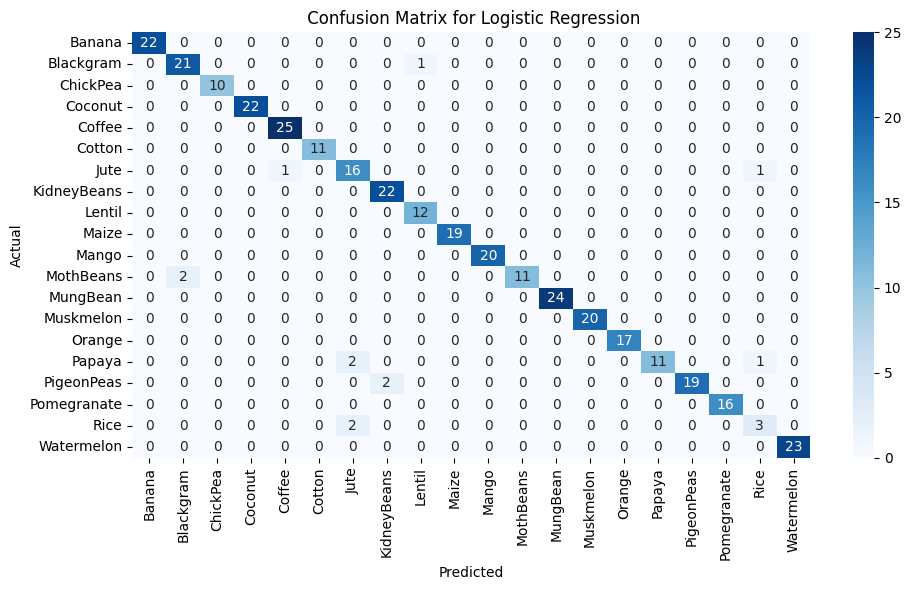


 Training KNN...
 Classification Report for KNN:

              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00        22
   Blackgram       1.00      1.00      1.00        22
    ChickPea       1.00      1.00      1.00        10
     Coconut       1.00      1.00      1.00        22
      Coffee       0.96      1.00      0.98        25
      Cotton       1.00      1.00      1.00        11
        Jute       0.89      0.94      0.92        18
 KidneyBeans       0.92      1.00      0.96        22
      Lentil       1.00      1.00      1.00        12
       Maize       1.00      1.00      1.00        19
       Mango       1.00      1.00      1.00        20
   MothBeans       1.00      1.00      1.00        13
    MungBean       1.00      1.00      1.00        24
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00      1.00      1.00        17
      Papaya       1.00      0.86      0.92        14
  PigeonPeas       1.00      0

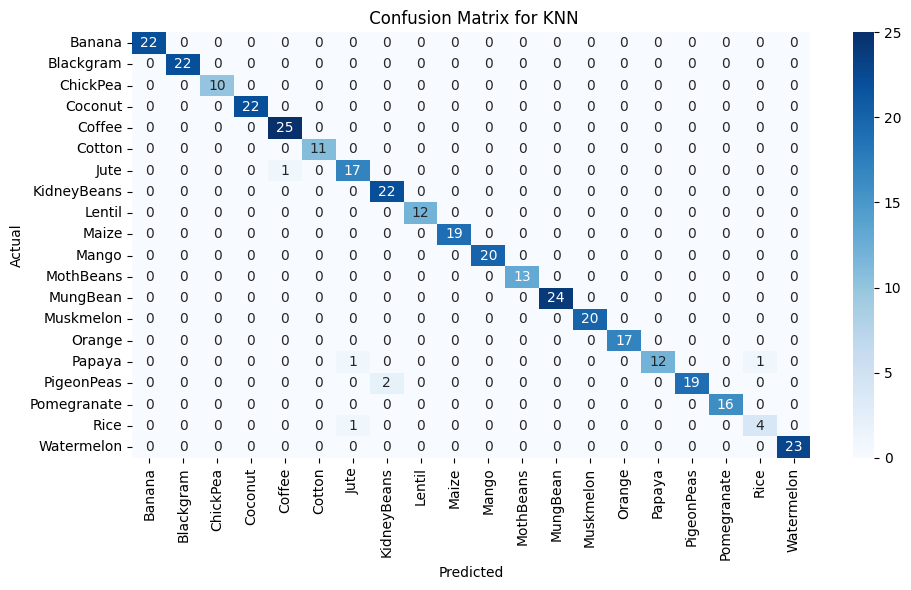

In [16]:
#  Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
df = df_iter_cleaned.copy()

# Encode target labels
le = LabelEncoder()
df['Crop'] = le.fit_transform(df['Crop'])

#  Features & Target
X = df.drop('Crop', axis=1)
y = df['Crop']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Save the scaler for future use in GUI
joblib.dump(scaler, "scaler.pkl")

# Define ML models
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier()
}

# Train, Evaluate, and Save Models
for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train, y_train)

    # Save model
    joblib.dump(model, f"{name.replace(' ', '_').lower()}.pkl")

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation
    print(f" Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f" Confusion Matrix for {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [18]:
import joblib
import numpy as np

# Load Label Encoder and Scaler
scaler = joblib.load("scaler.pkl")
label_encoder = le  # Already defined during model training

# Load all saved models
models = {
    "Decision Tree": joblib.load("decision_tree.pkl"),
    "Random Forest": joblib.load("random_forest.pkl"),
    "SVM": joblib.load("svm.pkl"),
    "Logistic Regression": joblib.load("logistic_regression.pkl"),
    "KNN": joblib.load("knn.pkl")
}

def predict_crop():
    print("\nEnter the following soil and environmental parameters for crop prediction:")
    N = int(input("Enter Nitrogen (N) value: "))
    P = int(input("Enter Phosphorus (P) value: "))
    K = int(input("Enter Potassium (K) value: "))
    temp = float(input("Enter Temperature (°C): "))
    humidity = float(input("Enter Humidity (%): "))
    pH = float(input("Enter soil pH value: "))
    rainfall = float(input("Enter Rainfall (mm): "))

    # Create feature vector
    features = np.array([[N, P, K, temp, humidity, pH, rainfall]])
    scaled_features = scaler.transform(features)

    # Predict using each model
    print("\n Crop Predictions from Different Models:")
    for name, model in models.items():
        pred = model.predict(scaled_features)
        crop_name = label_encoder.inverse_transform(pred)[0]
        print(f"{name}: {crop_name}")

# Run the function
predict_crop()



Enter the following soil and environmental parameters for crop prediction:


Enter Nitrogen (N) value:  90
Enter Phosphorus (P) value:  43
Enter Potassium (K) value:  45
Enter Temperature (°C):  26.5
Enter Humidity (%):  80
Enter soil pH value:  6.5
Enter Rainfall (mm):  150



 Crop Predictions from Different Models:
Decision Tree: Jute
Random Forest: Jute
SVM: Jute
Logistic Regression: Jute
KNN: Jute
